In [74]:
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [75]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

SEED = 122
TEST_YEARS = 5
HORIZON = 1      # weeks; target is future HORIZON-week log return
K_LAGS = 4       # temporal window length

set_seed(SEED)


In [76]:
DATA_PATH = r"C:\Programming\ETH\SS26\ISQT26\final\playground\market_data.xlsx"

df = pd.read_excel(DATA_PATH, sheet_name="US", engine="openpyxl", index_col=0)
namings = pd.read_excel(DATA_PATH, sheet_name="legend", engine="openpyxl", index_col=0)


In [90]:
def transform_data(X, Y, params=None, horizon=1, window=4, past_vol_windows=(4, 13, 26)):

    def safe_log(s):
        return np.log(s.where(s > 0))

    def dlog(s):
        return np.log(s / s.shift(horizon))

    def future_vol(s):
        """
        Target:
            Y_t = std(r_{t+h}, ..., r_{t+h+w-1})

        where:
            r_t = log(S_t / S_{t-1})

        For horizon=1, window=4:
            Y_t = std(r_{t+1}, r_{t+2}, r_{t+3}, r_{t+4})
        """
        r = np.log(s / s.shift(1))
        y = pd.Series(index=s.index, dtype=float)

        for t in range(len(s)):
            start = t + horizon
            end = start + window

            if end <= len(r):
                rr = r.iloc[start:end]

                if rr.notna().all():
                    y.iloc[t] = rr.std(ddof=0)

        return y

    def fisher(s):
        rho = s.clip(-1 + 1e-6, 1 - 1e-6)
        return np.arctanh(rho)

    def logit_prob(s):
        p = (s / 100).clip(1e-6, 1 - 1e-6)
        return np.log(p / (1 - p))

    Z = pd.DataFrame(index=X.index)

    Z["EMP"]  = X["EMP"]
    Z["PE"]   = safe_log(X["PE"])
    Z["CAPE"] = safe_log(X["CAPE"])
    Z["DY"]   = safe_log(X["DY"])
    Z["Rho"]  = fisher(X["Rho"])
    Z["MOV "] = safe_log(X["MOV "])

    Z["IR"]   = X["IR"]
    Z["RR"]   = X["RR"]
    Z["Y02"]  = X["Y02"]
    Z["Y10"]  = X["Y10"]
    Z["STP"]  = X["STP"]

    Z["CF"]   = X["CF"]
    Z["MG"]   = X["MG"]
    Z["RV"]   = X["RV"]
    Z["ED"]   = X["ED"]
    Z["UN"]   = X["UN"]
    Z["GDP"]  = X["GDP"]
    Z["M2"]   = X["M2"]
    Z["CPI"]  = X["CPI"]
    Z["DIL"]  = X["DIL"]

    Z["YSS"]  = np.log1p(X["YSS"])
    Z["NYF"]  = logit_prob(X["NYF"])

    Z["_AU"]  = dlog(X["_AU"])
    Z["_DXY"] = dlog(X["_DXY"])
    Z["_LCP"] = dlog(X["_LCP"])
    Z["_TY"]  = dlog(X["_TY"])
    Z["_OIL"] = dlog(X["_OIL"])

    Z["_VA"]  = dlog(X["_VA"])
    Z["_GR"]  = dlog(X["_GR"])

    # =========================
    # Past market volatility features
    # No leakage: these use only returns up to and including time t.
    # Target starts at t + horizon.
    # =========================

    mkt_ret = np.log(Y / Y.shift(1))

    Z["_MKT_ret_1"] = mkt_ret
    Z["_MKT_absret_1"] = mkt_ret.abs()

    for w in past_vol_windows:
        Z[f"_MKT_vol_{w}"] = mkt_ret.rolling(w).std(ddof=0)

    # =========================
    # Future volatility target
    # =========================

    y = future_vol(Y)
    y.name = "_MKT"

    data = pd.concat([Z, y], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    Z = data.drop(columns=["_MKT"])
    y = data["_MKT"]

    if params is None:
        params = {
            "X_mean": Z.mean(),
            "X_std": Z.std(ddof=0).replace(0, 1),
            "Y_mean": y.mean(),
            "Y_std": y.std(ddof=0) if y.std(ddof=0) != 0 else 1,
        }

    Z = (Z - params["X_mean"]) / params["X_std"]
    y = (y - params["Y_mean"]) / params["Y_std"]

    return Z, y, params


def split_transform_data(
    df,
    target="_MKT",
    test_years=5,
    horizon=1,
    window=4,
    past_vol_windows=(4, 13, 26),
):
    split_date = df.index.max() - pd.DateOffset(years=test_years)

    train = df.loc[df.index < split_date]
    test = df.loc[df.index >= split_date]

    X_train_raw = train.drop(columns=[target])
    Y_train_raw = train[target]

    X_test_raw = test.drop(columns=[target])
    Y_test_raw = test[target]

    X_train, Y_train, params = transform_data(
        X_train_raw,
        Y_train_raw,
        horizon=horizon,
        window=window,
        past_vol_windows=past_vol_windows,
    )

    X_test, Y_test, _ = transform_data(
        X_test_raw,
        Y_test_raw,
        params=params,
        horizon=horizon,
        window=window,
        past_vol_windows=past_vol_windows,
    )

    return X_train, X_test, Y_train, Y_test, params, split_date

In [91]:
X_train, X_test, Y_train, Y_test, params, split_date = split_transform_data(
    df,
    target="_MKT",
    test_years=TEST_YEARS,
    horizon=1,
    window=4,
    past_vol_windows=(4, 13, 26),
)

In [92]:
def make_rnn_windows(X, y, k=5, target_name="_MKT"):
    """
    Build temporal RNN samples.

    Input:
        X: DataFrame with shape (T, 29)
        y: Series with shape (T,)
        k: number of lagged observations per sample

    Output:
        X_seq: Tensor with shape (T-k+1, k, 29)
        y_seq: Tensor with shape (T-k+1, 1)
        idx:   DatetimeIndex aligned to y_seq

    Sample i uses [X_{t-k+1}, ..., X_t] to predict y_t.
    """
    y = y.copy()
    y.name = target_name

    data = (
        pd.concat([X, y], axis=1)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    X_clean = data.drop(columns=[target_name])
    y_clean = data[target_name]

    X_values = X_clean.to_numpy(dtype=np.float32)
    y_values = y_clean.to_numpy(dtype=np.float32)

    X_seq, y_seq, idx = [], [], []
    for end in range(k - 1, len(data)):
        start = end - k + 1
        X_seq.append(X_values[start:end + 1])
        y_seq.append(y_values[end])
        idx.append(data.index[end])

    X_seq = torch.tensor(np.stack(X_seq), dtype=torch.float32)
    y_seq = torch.tensor(np.asarray(y_seq), dtype=torch.float32).view(-1, 1)

    return X_seq, y_seq, pd.Index(idx), X_clean, y_clean


X_train_rnn, Y_train_rnn, train_idx, X_train_clean, Y_train_clean = make_rnn_windows(
    X_train,
    Y_train,
    k=K_LAGS,
)
X_test_rnn, Y_test_rnn, test_idx, X_test_clean, Y_test_clean = make_rnn_windows(
    X_test,
    Y_test,
    k=K_LAGS,
)

n_features = X_train_rnn.shape[-1]

print("X_train_rnn:", tuple(X_train_rnn.shape))  # (N_train, 5, 29)
print("Y_train_rnn:", tuple(Y_train_rnn.shape))
print("X_test_rnn: ", tuple(X_test_rnn.shape))   # (N_test, 5, 29)
print("Y_test_rnn: ", tuple(Y_test_rnn.shape))
print("n_features:", n_features)


X_train_rnn: (1693, 4, 34)
Y_train_rnn: (1693, 1)
X_test_rnn:  (228, 4, 34)
Y_test_rnn:  (228, 1)
n_features: 34


In [93]:
class RNNModel(torch.nn.Module):
    def __init__(self, n_features, hidden_size=8, seed=0):
        super().__init__()
        set_seed(seed)

        self.rnn = torch.nn.RNN(
            input_size=n_features,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.out = torch.nn.Linear(hidden_size, 1)

    def forward(self, X):
        # X has shape (batch, k, n_features), e.g. (N, 5, 29)
        h, _ = self.rnn(X)
        return self.out(h[:, -1, :])


In [94]:
def train_rnn(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    lr=1e-3,
    weight_decay=1e-3,
    epochs=1000,
    show_progress=True,
):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = torch.nn.MSELoss()

    hist = {
        "train_loss": [],
        "test_loss": [],
        "train_hit": [],
        "test_hit": [],
        "train_corr": [],
        "test_corr": [],
    }

    iterator = tqdm(range(epochs), desc="Training") if show_progress else range(epochs)

    for _ in iterator:
        model.train()
        opt.zero_grad()

        train_pred = model(X_train)
        train_loss = loss_fn(train_pred, y_train)
        train_loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(X_test)
            test_loss = loss_fn(test_pred, y_test)

            train_hit = (torch.sign(train_pred) == torch.sign(y_train)).float().mean()
            test_hit = (torch.sign(test_pred) == torch.sign(y_test)).float().mean()

            train_pred_np = train_pred.detach().cpu().numpy().ravel()
            test_pred_np = test_pred.detach().cpu().numpy().ravel()
            y_train_np = y_train.detach().cpu().numpy().ravel()
            y_test_np = y_test.detach().cpu().numpy().ravel()

            train_corr = np.corrcoef(y_train_np, train_pred_np)[0, 1]
            test_corr = np.corrcoef(y_test_np, test_pred_np)[0, 1]

        hist["train_loss"].append(train_loss.item())
        hist["test_loss"].append(test_loss.item())
        hist["train_hit"].append(train_hit.item())
        hist["test_hit"].append(test_hit.item())
        hist["train_corr"].append(train_corr)
        hist["test_corr"].append(test_corr)

        if show_progress:
            iterator.set_postfix({
                "train_loss": f"{train_loss.item():.4f}",
                "test_loss": f"{test_loss.item():.4f}",
                "train_hit": f"{train_hit.item():.3f}",
                "test_hit": f"{test_hit.item():.3f}",
                "test_corr": f"{test_corr:.3f}",
            })

    hist["model"] = model
    return hist


def evaluate_rnn(model, X_train, y_train, X_test, y_test):
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train).detach().cpu().numpy().ravel()
        test_pred = model(X_test).detach().cpu().numpy().ravel()

    y_train_np = y_train.detach().cpu().numpy().ravel()
    y_test_np = y_test.detach().cpu().numpy().ravel()

    return pd.Series({
        "train_mse": np.mean((y_train_np - train_pred) ** 2),
        "test_mse": np.mean((y_test_np - test_pred) ** 2),
        "train_hit": np.mean(np.sign(train_pred) == np.sign(y_train_np)),
        "test_hit": np.mean(np.sign(test_pred) == np.sign(y_test_np)),
        "train_corr": np.corrcoef(y_train_np, train_pred)[0, 1],
        "test_corr": np.corrcoef(y_test_np, test_pred)[0, 1],
    })

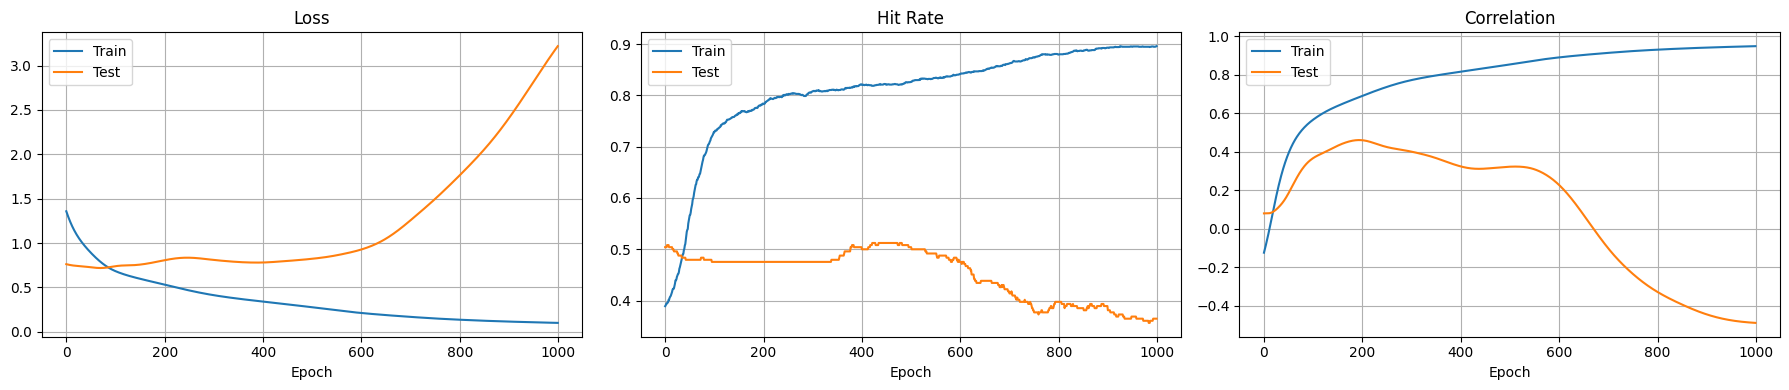

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hist["train_loss"], label="Train")
axes[0].plot(hist["test_loss"], label="Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist["train_hit"], label="Train")
axes[1].plot(hist["test_hit"], label="Test")
axes[1].set_title("Hit Rate")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(hist["train_corr"], label="Train")
axes[2].plot(hist["test_corr"], label="Test")
axes[2].set_title("Correlation")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()